# Thesis: Text-based industry momentum in Korea

## Brief Plan

- TNIC(Text-based Network Industry Classification) data is already created. 
- Using `alpha-excel` package I made, we will replicate the original paper by Hoberg and Phillips (2018) on Korean stock market.

## 0. Import libs, initialize alpha-excel instance with MONTHLY data

In [18]:
import sys
import argparse
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
from datetime import datetime

from alpha_excel2.core.facade import AlphaExcel
import checkpoint_utils as cp

# Parse command-line arguments
parser = argparse.ArgumentParser(description='Text-based industry momentum analysis with checkpoint caching')
parser.add_argument('--save-checkpoints', action='store_true',
                   help='Save intermediate results to checkpoints/ directory')
parser.add_argument('--validate-checkpoints', action='store_true',
                   help='Validate existing checkpoints against manifest')
parser.add_argument('--checkpoint-dir', type=str, default='checkpoints',
                   help='Directory for checkpoint files (default: checkpoints)')

# Only parse args if running as script (not in Jupyter)
if __name__ == "__main__" and not hasattr(sys, 'ps1'):
    args = parser.parse_args()
else:
    # Default args for Jupyter notebook
    args = argparse.Namespace(
        save_checkpoints=False,
        validate_checkpoints=False,
        checkpoint_dir='checkpoints'
    )

CHECKPOINT_DIR = Path(args.checkpoint_dir)
CHECKPOINT_DIR.mkdir(exist_ok=True)

# Global timing tracker
_section_times = {}
_section_start = None
_last_section = None

def print_section(title):
    """Print a formatted section header and track timing"""
    global _section_start, _last_section

    # Record end time of previous section
    if _last_section is not None and _section_start is not None:
        elapsed = time.time() - _section_start
        _section_times[_last_section] = elapsed
        print(f"\n[TIME] Section '{_last_section}' completed in {elapsed:.2f}s ({elapsed/60:.2f}m)")

    # Print new section header
    print("\n" + "=" * 80)
    print(f"  {title}")
    print("=" * 80 + "\n")

    # Start timing new section
    _section_start = time.time()
    _last_section = title

def print_total_time():
    """Print summary of all section times"""
    print("\n" + "=" * 80)
    print("  TIMING SUMMARY")
    print("=" * 80)
    total = 0
    for section, elapsed in _section_times.items():
        print(f"  {section:60s} {elapsed:8.2f}s ({elapsed/60:6.2f}m)")
        total += elapsed
    print("=" * 80)
    print(f"  {'TOTAL':60s} {total:8.2f}s ({total/60:6.2f}m)")
    print("=" * 80 + "\n")

def calculate_summary_stats_single(df, var_name):
    """
    Calculate summary statistics for a single 2D dataframe.

    Parameters:
    -----------
    df : pd.DataFrame
        2D dataframe (dates × securities)
    var_name : str
        Variable name for display

    Returns:
    --------
    dict
        Summary statistics: {'Variable', 'Mean', 'Std Dev', 'Min', 'Median', 'Max', 'N'}
    """
    values = df.stack().dropna()

    return {
        'Variable': var_name,
        'Mean': f'{values.mean():.4f}',
        'Std Dev': f'{values.std():.4f}',
        'Min': f'{values.min():.4f}',
        'Median': f'{values.median():.4f}',
        'Max': f'{values.max():.4f}',
        'N': f'{len(values):,}'
    }

def extract_turnover_windows(share_turnover_df, event_matrix, WINDOW_BEFORE=3, WINDOW_AFTER=12):
    """
    Extract turnover windows around peer shock events.

    Parameters:
    - share_turnover_df: DataFrame of turnover values (dates x symbols)
    - event_matrix: Boolean DataFrame marking high-quintile events
    - WINDOW_BEFORE: Months before event (default 3)
    - WINDOW_AFTER: Months after event (default 12)

    Returns:
    - List of turnover windows (numpy arrays)
    """
    WINDOW_LENGTH = WINDOW_BEFORE + 1 + WINDOW_AFTER

    turnover_windows = []
    used_events = set()
    date_to_idx = {date: idx for idx, date in enumerate(share_turnover_df.index)}

    for symbol in tqdm(event_matrix.columns, desc="Extracting windows"):
        event_dates = event_matrix.index[event_matrix[symbol]]

        for event_date in event_dates:
            event_idx = date_to_idx[event_date]

            # Check if we have enough data before and after
            if event_idx < WINDOW_BEFORE or event_idx + WINDOW_AFTER >= len(share_turnover_df):
                continue

            # Skip if this event's window overlaps with any previously used event
            if (symbol, event_idx - WINDOW_BEFORE) in used_events or (symbol, event_idx + WINDOW_AFTER) in used_events:
                continue

            # Extract turnover window (t-3 to t+12)
            start_idx = event_idx - WINDOW_BEFORE
            end_idx = event_idx + WINDOW_AFTER + 1

            turnover_window = share_turnover_df.iloc[start_idx:end_idx][symbol].values

            # Skip if any turnover is missing
            if pd.isna(turnover_window).any():
                continue

            # Skip if any turnover is near-zero or zero (suspicious)
            if (np.isclose(turnover_window, 0.0)).any():
                continue

            # Store this window
            turnover_windows.append(turnover_window)

            # Mark the entire turnover window as used (t-3 to t+12)
            for i in range(-WINDOW_BEFORE, WINDOW_AFTER + 1):
                used_events.add((symbol, event_idx + i))

    return turnover_windows

def normalize_and_aggregate(turnover_windows, WINDOW_BEFORE=3):
    """
    Normalize turnover windows by first position (t=-WINDOW_BEFORE) and aggregate.

    Parameters:
    - turnover_windows: List of turnover window arrays
    - WINDOW_BEFORE: Number of months before event (determines normalization point)
                     e.g., WINDOW_BEFORE=3 means normalize by t=-3
                     e.g., WINDOW_BEFORE=14 means normalize by t=-14

    Returns:
    - normalized_turnover: Normalized turnover values (numpy array)
    """
    turnover_windows_array = np.array(turnover_windows)

    # Average first, then normalize (matching figure1_graph_a.py)
    avg_turnover = turnover_windows_array.mean(axis=0)

    # Normalize by first position (t=-WINDOW_BEFORE)
    # Index 0 corresponds to t=-WINDOW_BEFORE
    normalized_turnover = avg_turnover / avg_turnover[0]

    return normalized_turnover

def plot_results(relative_months, normalized_turnover, n_events, method_name, WINDOW_BEFORE=3, normalization_point=-3, legend_label=None, color='#2E86AB'):
    """
    Plot Figure 1A: Turnover around peer shocks.

    Parameters:
    - relative_months: X-axis values (e.g., -15 to +15)
    - normalized_turnover: Normalized turnover values
    - n_events: Number of event windows
    - method_name: String describing the method (for title)
    - WINDOW_BEFORE: Number of months before event (determines window start)
    - normalization_point: Which relative month was used for normalization (default -3)
    - legend_label: Label for the data series in legend (default: method_name)
    - color: Color for the line plot (default: '#2E86AB')

    Returns:
    - fig, ax: Matplotlib figure and axis objects
    """
    fig, ax = plt.subplots(figsize=(12, 6))

    # Use legend_label if provided, otherwise use method_name
    if legend_label is None:
        legend_label = method_name

    ax.plot(relative_months, normalized_turnover,
            marker='o', linewidth=2, markersize=6,
            color=color, label=legend_label)

    # Add horizontal line at y=1.0
    ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, linewidth=1)

    # Add vertical line at t=0 (event month)
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.5, linewidth=1,
               label='Peer Shock (t=0)')

    # Add vertical line at normalization point
    ax.axvline(x=normalization_point, color='blue', linestyle='--', alpha=0.5, linewidth=1,
               label=f't={normalization_point} (Normalization Point)')

    # Formatting
    ax.set_xlabel('Months Relative to High-Quintile Peer Return', fontsize=12)
    ax.set_ylabel('Relative Average Stock Turnover', fontsize=12)
    ax.set_title(f'Figure 1A: Turnover Following High-Quintile Peer Shock\n' +
                 f'({method_name}, N={n_events:,} events)',
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=10, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(relative_months)

    # Set y-axis limits
    y_min = normalized_turnover.min() * 0.95
    y_max = normalized_turnover.max() * 1.05
    ax.set_ylim(y_min, y_max)

    plt.tight_layout()

    return fig, ax

def plot_comparison(relative_months, turnover_data_list, WINDOW_BEFORE=3, normalization_point=-3, title_suffix=""):
    """
    Plot comparison of multiple turnover series on the same chart.

    Parameters:
    - relative_months: X-axis values (e.g., -3 to +12)
    - turnover_data_list: List of dicts, each containing:
        - 'data': normalized turnover array
        - 'label': legend label
        - 'color': line color
        - 'marker': marker style (default: 'o')
        - 'n_events': number of events (for label)
    - WINDOW_BEFORE: Number of months before event (default 3)
    - normalization_point: Which relative month was used for normalization (default -3)
    - title_suffix: Additional text for title (default: "")

    Returns:
    - fig, ax: Matplotlib figure and axis objects
    """
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot each series
    for series_info in turnover_data_list:
        data = series_info['data']
        label = series_info['label']
        color = series_info['color']
        marker = series_info.get('marker', 'o')
        n_events = series_info.get('n_events', None)

        # Add event count to label if provided
        if n_events is not None:
            label = f"{label} (N={n_events:,})"

        ax.plot(relative_months, data,
                marker=marker, linewidth=2, markersize=6,
                color=color, label=label)

    # Add horizontal line at y=1.0
    ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, linewidth=1)

    # Add vertical line at t=0 (event month)
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.5, linewidth=1,
               label='Peer Shock (t=0)')

    # Add vertical line at normalization point
    ax.axvline(x=normalization_point, color='blue', linestyle='--', alpha=0.5, linewidth=1,
               label=f't={normalization_point} (Normalization Point)')

    # Formatting
    ax.set_xlabel('Months Relative to High-Quintile Peer Return', fontsize=12)
    ax.set_ylabel('Relative Average Stock Turnover', fontsize=12)

    title = 'Figure 1A: Turnover Following High-Quintile Peer Shock'
    if title_suffix:
        title += f'\n{title_suffix}'

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=10, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(relative_months)

    # Set y-axis limits based on all data
    all_data = np.concatenate([series['data'] for series in turnover_data_list])
    y_min = all_data.min() * 0.95
    y_max = all_data.max() * 1.05
    ax.set_ylim(y_min, y_max)

    plt.tight_layout()

    return fig, ax

In [19]:
# ========================================================================
#  SECTION 1: INITIALIZE WITH MONTHLY FIELD AS UNIVERSE
# ========================================================================

print_section("Initialize AlphaExcel with monthly_adj_close as Universe")

print("""
Using monthly_adj_close as the universe field:
- This is a MONTHLY field (one value per month)
- config/data.yaml: forward_fill=true for monthly fields
- Universe mask derived as: ~monthly_adj_close.isna()
- Forward-filled to daily frequency automatically
""")

print("\nInitializing AlphaExcel...")
print("  universe_field='monthly_adj_close'")
print("  Time range: 2010-01-01 to 2025-09-30")
print("")

ae_monthly = AlphaExcel(
    start_time='2010-01-01',
    end_time='2025-09-30',
    universe_field='monthly_adj_close',  # Use monthly field for universe
    config_path='./config'
)

print(f"[OK] AlphaExcel initialized successfully!")
print(f"     Universe field: monthly_adj_close")
print(f"     Time range: {ae_monthly._start_time} to {ae_monthly._end_time}")
print(f"     Universe shape: {ae_monthly._universe_mask._data.shape}")


  Initialize AlphaExcel with monthly_adj_close as Universe


Using monthly_adj_close as the universe field:
- This is a MONTHLY field (one value per month)
- config/data.yaml: forward_fill=true for monthly fields
- Universe mask derived as: ~monthly_adj_close.isna()
- Forward-filled to daily frequency automatically


Initializing AlphaExcel...
  universe_field='monthly_adj_close'
  Time range: 2010-01-01 to 2025-09-30

[OK] AlphaExcel initialized successfully!
     Universe field: monthly_adj_close
     Time range: 2010-01-01 00:00:00 to 2025-09-30 00:00:00
     Universe shape: (189, 3263)


In [20]:
# Initialize operators and field accessor for monthly instance
om = ae_monthly.ops
fm = ae_monthly.field

In [21]:
# ========================================================================
#  SECTION 2: INITIALIZE SECOND INSTANCE FOR DAILY DATA (TURNOVER)
# ========================================================================

print_section("Initialize Second AlphaExcel Instance for Daily Data")

print("""
Why second instance?
- Monthly instance (ae): For peer returns calculation (elegant with monthly data)
- Daily instance (ae_daily): For turnover calculation (need daily average, not end-of-month)
- This gives us best of both worlds!
""")

print("\nInitializing daily AlphaExcel...")
print("  universe_field=None (no universe masking)")
print("  Time range: 2010-01-01 to 2025-09-30")
print("")

ae_daily = AlphaExcel(
    start_time='2010-01-01',
    end_time='2025-09-30',
    universe_field=None,  # No universe masking for daily data
    config_path='./config'
)

print(f"[OK] Daily AlphaExcel initialized successfully!")
print(f"     Universe field: None (no masking)")
print(f"     Time range: {ae_daily._start_time} to {ae_daily._end_time}")


  Initialize Second AlphaExcel Instance for Daily Data


Why second instance?
- Monthly instance (ae): For peer returns calculation (elegant with monthly data)
- Daily instance (ae_daily): For turnover calculation (need daily average, not end-of-month)
- This gives us best of both worlds!


Initializing daily AlphaExcel...
  universe_field=None (no universe masking)
  Time range: 2010-01-01 to 2025-09-30

[OK] Daily AlphaExcel initialized successfully!
     Universe field: None (no masking)
     Time range: 2010-01-01 00:00:00 to 2025-09-30 00:00:00


In [22]:
# Initialize operators and field accessor for daily instance
od = ae_daily.ops
fd = ae_daily.field

## 3. Load Monthly Data for Peer Returns

Monthly fields (from monthly instance):
- fnguide_industry_group: Industry classification
- monthly_return_pct: Monthly returns

In [23]:
print_section("Load Monthly Data for Peer Returns")

print("Loading industry classification data...")
industry_group = fm('fnguide_industry_group')
sector = fm('fnguide_sector')

print("\n[OK] Monthly classification fields loaded!")


  Load Monthly Data for Peer Returns

Loading industry classification data...

[OK] Monthly classification fields loaded!


## 4. Calculate Share Turnover from Daily Data

Why daily data?
- Monthly aggregated data only captures end-of-month values
- We need AVERAGE turnover during the month
- Solution: Calculate daily turnover, then resample to monthly mean

In [24]:
print_section("Calculate Share Turnover from Daily Data")

print("Step 1: Load daily trading data...")
trading_value_daily = fd('fnguide_trading_value')
market_cap_daily = fd('fnguide_market_cap')

print("\nStep 2: Convert to DataFrames...")
trading_value_df = trading_value_daily.to_df()
market_cap_df = market_cap_daily.to_df()

print(f"  Trading value shape: {trading_value_df.shape}")
print(f"  Market cap shape: {market_cap_df.shape}")

print("\nStep 3: Aggregate to monthly first, then calculate turnover ratio...")
# CORRECT: Aggregate first, then calculate ratio (not average of ratios!)
# Sum trading value over month (total value traded)
monthly_trading_value = trading_value_df.resample('ME').sum()
# Average market cap over month (average market cap during month)
monthly_market_cap = market_cap_df.resample('ME').mean()

print(f"  Monthly trading value shape: {monthly_trading_value.shape}")
print(f"  Monthly market cap shape: {monthly_market_cap.shape}")
print(f"  Monthly trading value mean: {monthly_trading_value.mean().mean():,.0f}")
print(f"  Monthly market cap mean: {monthly_market_cap.mean().mean():,.0f}")

print("\nStep 4: Calculate turnover ratio = sum(trading_value) / mean(market_cap)...")
share_turnover_df = monthly_trading_value / monthly_market_cap

print(f"  Monthly turnover shape: {share_turnover_df.shape}")
print(f"  Monthly turnover mean: {share_turnover_df.mean().mean():.6f}")
print(f"  Monthly turnover median: {share_turnover_df.median().median():.6f}")

print("\n[OK] Share turnover calculated from daily data (aggregated to monthly)!")

"""
# COMMENTED OUT: Method 2 - Monthly Data Turnover Calculation
# This section is preserved but not used in main analysis

# %% [markdown]
# ## 4b. Calculate Share Turnover from Monthly Data (for comparison)
#
# Alternative method:
# - Use monthly_trading_volume and monthly_float_shares directly
# - This captures end-of-month values, not averages

# %%
print_section("Calculate Share Turnover from Monthly Data (Comparison)")

print("Loading monthly trading data...")
monthly_trading_volume = fm('monthly_trading_volume')
monthly_float_shares = fm('monthly_float_shares')

print("\nCalculating monthly turnover (volume / shares)...")
share_turnover_monthly_alpha = monthly_trading_volume / monthly_float_shares

print("\nConverting to DataFrame...")
share_turnover_monthly_df = share_turnover_monthly_alpha.to_df()

print(f"  Monthly turnover shape: {share_turnover_monthly_df.shape}")
print(f"  Monthly turnover mean: {share_turnover_monthly_df.mean().mean():.6f}")
print(f"  Monthly turnover median: {share_turnover_monthly_df.median().median():.6f}")

print("\n[OK] Monthly turnover calculated!")
"""


  Calculate Share Turnover from Daily Data

Step 1: Load daily trading data...

Step 2: Convert to DataFrames...
  Trading value shape: (3879, 3264)
  Market cap shape: (3879, 3264)

Step 3: Aggregate to monthly first, then calculate turnover ratio...
  Monthly trading value shape: (189, 3264)
  Monthly market cap shape: (189, 3264)
  Monthly trading value mean: 78,448,423,786
  Monthly market cap mean: 680,443,566,660

Step 4: Calculate turnover ratio = sum(trading_value) / mean(market_cap)...
  Monthly turnover shape: (189, 3264)
  Monthly turnover mean: 0.481800
  Monthly turnover median: 0.137353

[OK] Share turnover calculated from daily data (aggregated to monthly)!


'\n# COMMENTED OUT: Method 2 - Monthly Data Turnover Calculation\n# This section is preserved but not used in main analysis\n\n# %% [markdown]\n# ## 4b. Calculate Share Turnover from Monthly Data (for comparison)\n#\n# Alternative method:\n# - Use monthly_trading_volume and monthly_float_shares directly\n# - This captures end-of-month values, not averages\n\n# %%\nprint_section("Calculate Share Turnover from Monthly Data (Comparison)")\n\nprint("Loading monthly trading data...")\nmonthly_trading_volume = fm(\'monthly_trading_volume\')\nmonthly_float_shares = fm(\'monthly_float_shares\')\n\nprint("\nCalculating monthly turnover (volume / shares)...")\nshare_turnover_monthly_alpha = monthly_trading_volume / monthly_float_shares\n\nprint("\nConverting to DataFrame...")\nshare_turnover_monthly_df = share_turnover_monthly_alpha.to_df()\n\nprint(f"  Monthly turnover shape: {share_turnover_monthly_df.shape}")\nprint(f"  Monthly turnover mean: {share_turnover_monthly_df.mean().mean():.6f}")\np

## 5. Calculate Industry Peer Returns (Monthly Data)

For each firm i in industry G at time t:
- Peer return = equal-weighted average of all other firms in same industry
- Formula: peer_return_i = (sum of all returns in G - return_i) / (N_G - 1)
- This excludes the focal firm from its own peer calculation

In [25]:
print_section("Calculate Industry Peer Returns")

print("Loading monthly returns...")
monthly_returns = fm('monthly_return_pct') / 100

print("\nCalculating peer returns (elegant one-liner with alpha-excel)...")
sic_peer_returns = (om.group_sum(monthly_returns, industry_group) - monthly_returns) / (om.group_count(industry_group) - 1)

print("\n[OK] Peer returns calculated!")


  Calculate Industry Peer Returns

Loading monthly returns...

Calculating peer returns (elegant one-liner with alpha-excel)...

[OK] Peer returns calculated!


## 6. Convert AlphaData to DataFrame

In [26]:
print_section("Convert to DataFrames")

monthly_returns_df = monthly_returns.to_df()
sic_peer_returns_df = sic_peer_returns.to_df()

print(f"Monthly returns shape: {monthly_returns_df.shape}")
print(f"Peer returns shape: {sic_peer_returns_df.shape}")
print(f"Share turnover shape: {share_turnover_df.shape}")

print("\n[OK] All data converted to DataFrames!")

# Checkpoint: Save core return data
if args.save_checkpoints:
    print("\n[CHECKPOINT] Saving core return data...")
    cp.save_checkpoint(monthly_returns_df, 'checkpoint_05_own_returns.parquet', CHECKPOINT_DIR)
    cp.save_checkpoint(sic_peer_returns_df, 'checkpoint_04_sic_peer_returns.parquet', CHECKPOINT_DIR)


  Convert to DataFrames

Monthly returns shape: (189, 3263)
Peer returns shape: (189, 3263)
Share turnover shape: (189, 3264)

[OK] All data converted to DataFrames!


## 4. Identify High-Quintile Peer Shock Events

Event definition:
- High-quintile = top 20% of cross-sectional peer returns each month
- For each month, calculate 80th percentile of all peer returns
- Mark firms whose peer return >= threshold as having an event

In [27]:
print_section("Identify High-Quintile Peer Shock Events")

quintile_threshold = 0.80  # Top 20%

print(f"Quintile threshold: {quintile_threshold} (top {(1-quintile_threshold)*100:.0f}%)")
print("\nIdentifying events cross-sectionally for each month...")

event_matrix = pd.DataFrame(
    index=sic_peer_returns_df.index,
    columns=sic_peer_returns_df.columns,
    dtype=bool
)

for date in sic_peer_returns_df.index:
    # Get peer returns for this date (cross-section)
    peer_returns_date = sic_peer_returns_df.loc[date]
    valid_returns = peer_returns_date.dropna()

    if len(valid_returns) > 0:
        # Calculate 80th percentile
        threshold = valid_returns.quantile(quintile_threshold)

        # Mark events (peer return >= threshold)
        event_matrix.loc[date] = peer_returns_date >= threshold
    else:
        event_matrix.loc[date] = False

event_matrix = event_matrix.fillna(False)

total_events = event_matrix.sum().sum()
print(f"\n[OK] Events identified!")
print(f"     Total events: {total_events:,}")
print(f"     Mean events per firm: {event_matrix.sum(axis=0).mean():.1f}")
print(f"     Mean events per month: {event_matrix.sum(axis=1).mean():.1f}")


  Identify High-Quintile Peer Shock Events

Quintile threshold: 0.8 (top 20%)

Identifying events cross-sectionally for each month...

[OK] Events identified!
     Total events: 78,202
     Mean events per firm: 24.0
     Mean events per month: 413.8


## 5. Extract Turnover Windows Around Events (Both Methods)

Window structure:
- t-3 to t+12 (16 months total)
- t=0 is the event month (high-quintile peer shock)
- Require complete data (no missing turnover values)
- Prevent overlapping windows (earlier events take priority)

In [28]:
WINDOW_BEFORE = 3
WINDOW_AFTER = 12
WINDOW_LENGTH = WINDOW_BEFORE + 1 + WINDOW_AFTER  # 16 months total

print_section("Extract Turnover Windows - Method 1: Daily Aggregation")
turnover_windows_daily = extract_turnover_windows(
    share_turnover_df,
    event_matrix,
    WINDOW_BEFORE,
    WINDOW_AFTER
)
print(f"[OK] Daily method: {len(turnover_windows_daily):,} valid windows")
print(f"     Acceptance rate: {len(turnover_windows_daily) / total_events * 100:.1f}%")

"""
# COMMENTED OUT: Method 2 turnover window extraction
print_section("Extract Turnover Windows - Method 2: Monthly Data")
turnover_windows_monthly = extract_turnover_windows(
    share_turnover_monthly_df,
    event_matrix,
    WINDOW_BEFORE,
    WINDOW_AFTER
)
print(f"[OK] Monthly method: {len(turnover_windows_monthly):,} valid windows")
print(f"     Acceptance rate: {len(turnover_windows_monthly) / total_events * 100:.1f}%")

# %%
share_turnover_df.shape, share_turnover_monthly_df.shape
"""


  Extract Turnover Windows - Method 1: Daily Aggregation



Extracting windows: 100%|██████████| 3263/3263 [00:01<00:00, 1664.05it/s]

[OK] Daily method: 16,957 valid windows
     Acceptance rate: 21.7%


'\n# COMMENTED OUT: Method 2 turnover window extraction\nprint_section("Extract Turnover Windows - Method 2: Monthly Data")\nturnover_windows_monthly = extract_turnover_windows(\n    share_turnover_monthly_df,\n    event_matrix,\n    WINDOW_BEFORE,\n    WINDOW_AFTER\n)\nprint(f"[OK] Monthly method: {len(turnover_windows_monthly):,} valid windows")\nprint(f"     Acceptance rate: {len(turnover_windows_monthly) / total_events * 100:.1f}%")\n\n# %%\nshare_turnover_df.shape, share_turnover_monthly_df.shape\n'

## 6. Normalize and Aggregate (Both Methods)

Paper methodology: "All results are scaled so that the first month has unit turnover"
- First month = t=-3
- Average first, then normalize

In [29]:
print_section("Normalize - Method 1: Daily Aggregation")
normalized_turnover_daily = normalize_and_aggregate(turnover_windows_daily, WINDOW_BEFORE)
print(f"[OK] Daily method normalized!")
print(f"Normalized turnover (t={-WINDOW_BEFORE} = 1.0):")
for i, val in enumerate(normalized_turnover_daily):
    rel_month = i - WINDOW_BEFORE
    print(f"  t{rel_month:+3d}: {val:.4f}")

"""
# COMMENTED OUT: Method 2 normalization
print_section("Normalize - Method 2: Monthly Data")
normalized_turnover_monthly = normalize_and_aggregate(turnover_windows_monthly, WINDOW_BEFORE)
print(f"[OK] Monthly method normalized!")
print(f"Normalized turnover (t={-WINDOW_BEFORE} = 1.0):")
for i, val in enumerate(normalized_turnover_monthly):
    rel_month = i - WINDOW_BEFORE
    print(f"  t{rel_month:+3d}: {val:.4f}")
"""


  Normalize - Method 1: Daily Aggregation

[OK] Daily method normalized!
Normalized turnover (t=-3 = 1.0):
  t -3: 1.0000
  t -2: 0.9189
  t -1: 0.9261
  t +0: 0.9523
  t +1: 0.9778
  t +2: 0.9579
  t +3: 0.9501
  t +4: 0.9023
  t +5: 0.8951
  t +6: 0.8869
  t +7: 0.8867
  t +8: 0.9058
  t +9: 0.8910
  t+10: 0.9089
  t+11: 0.9390
  t+12: 0.9345


'\n# COMMENTED OUT: Method 2 normalization\nprint_section("Normalize - Method 2: Monthly Data")\nnormalized_turnover_monthly = normalize_and_aggregate(turnover_windows_monthly, WINDOW_BEFORE)\nprint(f"[OK] Monthly method normalized!")\nprint(f"Normalized turnover (t={-WINDOW_BEFORE} = 1.0):")\nfor i, val in enumerate(normalized_turnover_monthly):\n    rel_month = i - WINDOW_BEFORE\n    print(f"  t{rel_month:+3d}: {val:.4f}")\n'

## 7. Plot Results: Figure 1A (Both Methods)

Plot normalized turnover around peer shocks
- Normalized by t=-3 (paper's method: first month has unit turnover)
- Shows turnover pattern from t-3 to t+12 months
- Compare daily aggregation vs monthly data methods


  Plot Figure 1A - Method 1: Daily Aggregation



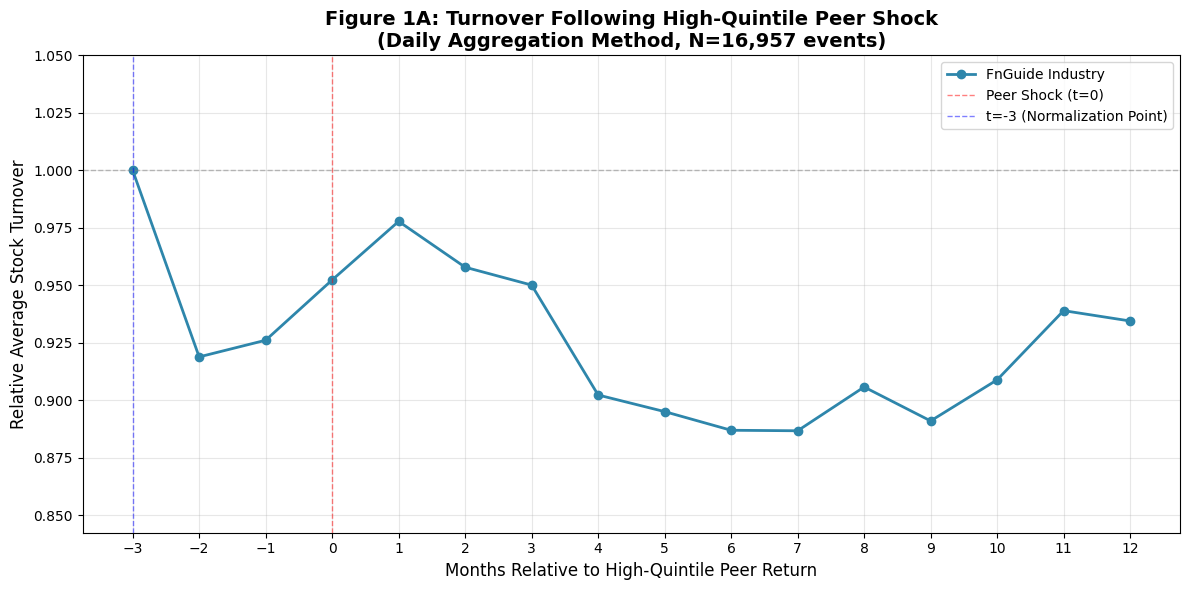

[OK] Daily aggregation plot complete!

  ANALYSIS COMPLETE!


In [30]:
relative_months = np.arange(-WINDOW_BEFORE, WINDOW_AFTER + 1)

print_section("Plot Figure 1A - Method 1: Daily Aggregation")
fig1, ax1 = plot_results(
    relative_months,
    normalized_turnover_daily,
    len(turnover_windows_daily),
    "FnGuide Industry (Daily Aggregation)",
    WINDOW_BEFORE,
    -WINDOW_BEFORE,  # Normalization point is t=-3
    legend_label="FnGuide Industry",
    color='#2E86AB'
)
plt.show()
print("[OK] Daily aggregation plot complete!")

"""
# COMMENTED OUT: Method 2 plotting and comparison
print_section("Plot Figure 1A - Method 2: Monthly Data")
fig2, ax2 = plot_results(
    relative_months,
    normalized_turnover_monthly,
    len(turnover_windows_monthly),
    "Monthly Data Method",
    WINDOW_BEFORE,
    -WINDOW_BEFORE  # Normalization point is t=-3
)
plt.show()
print("[OK] Monthly data plot complete!")

# %%
print_section("Comparison: Daily vs Monthly Methods")

print("Daily Aggregation Method:")
print(f"  Valid windows: {len(turnover_windows_daily):,}")
print("  Normalized turnover:")
for i, val in enumerate(normalized_turnover_daily):
    rel_month = i - WINDOW_BEFORE
    print(f"    t{rel_month:+3d}: {val:.4f}")

print("\nMonthly Data Method:")
print(f"  Valid windows: {len(turnover_windows_monthly):,}")
print("  Normalized turnover:")
for i, val in enumerate(normalized_turnover_monthly):
    rel_month = i - WINDOW_BEFORE
    print(f"    t{rel_month:+3d}: {val:.4f}")

print("\nDifference (Daily - Monthly):")
diff = normalized_turnover_daily - normalized_turnover_monthly
for i, val in enumerate(diff):
    rel_month = i - WINDOW_BEFORE
    print(f"    t{rel_month:+3d}: {val:+.4f}")

print(f"\nMean absolute difference: {np.abs(diff).mean():.4f}")
print(f"Max absolute difference: {np.abs(diff).max():.4f}")
"""

print("\n" + "=" * 80)
print("  ANALYSIS COMPLETE!")
print("=" * 80)

## 8. Load TNIC Peer Group Data

Load TNIC peer group data from tnic module outputs.
- Files: data/korean_tnic/by_year/tnic_all_pairs_{year}.csv
- Years: 2010-2025 (16 years)
- Structure: Pairwise similarity scores, peer relationships, FnGuide comparison

In [31]:
print_section("Load TNIC Peer Group Data from tnic module outputs")

# Define path to TNIC data directory
tnic_data_dir = Path("data/korean_tnic/by_year")

# Years to load (2010-2025)
tnic_years = range(2010, 2026)

# Load and concatenate all TNIC pair data
print("Loading TNIC peer group data from all years...")
tnic_dfs = []

for year in tqdm(tnic_years, desc="Loading TNIC files"):
    file_path = tnic_data_dir / f"tnic_all_pairs_{year}.csv"

    if file_path.exists():
        # CRITICAL: Load stock codes as strings, not integers (000020 ≠ 20)
        df_year = pd.read_csv(file_path, dtype={'stock_code_i': str, 'stock_code_j': str})
        tnic_dfs.append(df_year)
        print(f"  [OK] Loaded {year}: {len(df_year):,} pairs")
    else:
        print(f"  [MISSING] {year}: {file_path}")

# Concatenate all years
tnic_all_pairs = pd.concat(tnic_dfs, ignore_index=True)

print(f"\n[OK] TNIC data loaded!")
print(f"     Total firm-pairs: {len(tnic_all_pairs):,}")
print(f"     Years: {tnic_all_pairs['year'].min()} - {tnic_all_pairs['year'].max()}")
print(f"     Total TNIC peer relationships (is_same_tnic=True): {tnic_all_pairs['is_same_tnic'].sum():,}")
print(f"     Shape: {tnic_all_pairs.shape}")

# Display sample
print(f"\nSample TNIC data:")
print(tnic_all_pairs.head(10))

# Display column info
print(f"\nColumn types:")
print(tnic_all_pairs.dtypes)

print("\n[OK] TNIC peer group data ready for analysis!")


  Load TNIC Peer Group Data from tnic module outputs

Loading TNIC peer group data from all years...


Loading TNIC files:   6%|▋         | 1/16 [00:00<00:11,  1.28it/s]

  [OK] Loaded 2010: 464,166 pairs


Loading TNIC files:  12%|█▎        | 2/16 [00:01<00:11,  1.20it/s]

  [OK] Loaded 2011: 522,753 pairs


...

Loading TNIC files:  94%|█████████▍| 15/16 [00:25<00:02,  2.59s/it]

  [OK] Loaded 2024: 1,732,591 pairs


Loading TNIC files: 100%|██████████| 16/16 [00:29<00:00,  1.81s/it]

  [OK] Loaded 2025: 1,971,105 pairs



[OK] TNIC data loaded!
     Total firm-pairs: 14,882,161
     Years: 2010 - 2025
     Total TNIC peer relationships (is_same_tnic=True): 465,911
     Shape: (14882161, 13)

Sample TNIC data:
   year  firm_i  firm_j stock_code_i stock_code_j  similarity  threshold  \
0  2010       0       1       000020       000050    0.002488        0.1   
1  2010       0       2       000020       000070    0.047203        0.1   
2  2010       0       3       000020       000080   -0.002087        0.1   
3  2010       0       4       000020       000100    0.141015        0.1   
4  2010       0       5       000020       000120    0.019946        0.1   
5  2010       0       6       000020       000140   -0.018611        0.1   
6  2010       0       7       000020       000150   -0.006524        0.1   
7  2010       0       8       000020       000210    0.016855        0.1   
8  2010       0       9       000020       000220    0.176435        0.1   
9  2010       0      10       000020       00023

## 8.5. DEBUG: Inspect Stock Code Formats

Diagnose stock code format differences between FnGuide and TNIC datasets
- FnGuide may use prefix (e.g., "A000020")
- TNIC uses zero-padded codes (e.g., "000020")
- Need to identify pattern for conversion

In [32]:
print_section("DEBUG: Inspect Stock Code Formats")

print("Checking stock code formats across datasets...\n")

# Check FnGuide/SIC format (from monthly_returns_df)
print("=== FnGuide/SIC Data (monthly_returns_df.columns) ===")
sample_fnguide = list(monthly_returns_df.columns[:10])
print(f"Sample stock codes: {sample_fnguide}")
print(f"Type: {type(sample_fnguide[0])}")
print(f"Lengths: {[len(str(s)) for s in sample_fnguide[:5]]}")
print(f"First char is alpha? {[str(s)[0].isalpha() if len(str(s)) > 0 else False for s in sample_fnguide[:5]]}")

# Check TNIC format
print("\n=== TNIC Data (tnic_all_pairs['stock_code_i']) ===")
sample_tnic = list(tnic_all_pairs['stock_code_i'].unique()[:10])
print(f"Sample stock codes: {sample_tnic}")
print(f"Type: {type(sample_tnic[0])}")
print(f"Lengths: {[len(str(s)) for s in sample_tnic[:5]]}")
print(f"All digits? {[str(s).isdigit() for s in sample_tnic[:5]]}")

# Check sic_peer_returns_df format
print("\n=== sic_peer_returns_df.columns ===")
sample_sic = list(sic_peer_returns_df.columns[:10])
print(f"Sample stock codes: {sample_sic}")
print(f"Same as monthly_returns? {sample_sic == sample_fnguide}")

# Identify conversion pattern
print("\n=== Pattern Analysis ===")
fnguide_len = len(str(sample_fnguide[0]))
tnic_len = len(str(sample_tnic[0]))

if fnguide_len > tnic_len:
    print(f"FnGuide codes are longer ({fnguide_len} vs {tnic_len})")
    print(f"FnGuide example: '{sample_fnguide[0]}'")
    print(f"  -> First char: '{str(sample_fnguide[0])[0]}'")
    print(f"  -> Remaining: '{str(sample_fnguide[0])[1:]}'")
    print(f"TNIC example: '{sample_tnic[0]}'")
    print(f"\n-> Conversion rule: Remove first character from FnGuide to get TNIC format")

    # Test conversion
    test_fnguide = str(sample_fnguide[0])
    test_tnic_converted = test_fnguide[1:]
    print(f"\nTest conversion:")
    print(f"  FnGuide '{test_fnguide}' -> '{test_tnic_converted}'")
    print(f"  Matches TNIC format? Length={len(test_tnic_converted)}, All digits={test_tnic_converted.isdigit()}")
else:
    print(f"Unexpected: FnGuide and TNIC have same length ({fnguide_len})")

print("\n[OK] Stock code format inspection complete!")


  DEBUG: Inspect Stock Code Formats

Checking stock code formats across datasets...

=== FnGuide/SIC Data (monthly_returns_df.columns) ===
Sample stock codes: ['A000020', 'A000030', 'A000040', 'A000050', 'A000060', 'A000070', 'A000080', 'A000100', 'A000120', 'A000140']
Type: <class 'str'>
Lengths: [7, 7, 7, 7, 7]
First char is alpha? [True, True, True, True, True]

=== TNIC Data (tnic_all_pairs['stock_code_i']) ===
Sample stock codes: ['000020', '000050', '000070', '000080', '000100', '000120', '000140', '000150', '000210', '000220']
Type: <class 'str'>
Lengths: [6, 6, 6, 6, 6]
All digits? [True, True, True, True, True]

=== sic_peer_returns_df.columns ===
Sample stock codes: ['A000020', 'A000030', 'A000040', 'A000050', 'A000060', 'A000070', 'A000080', 'A000100', 'A000120', 'A000140']
Same as monthly_returns? True

=== Pattern Analysis ===
FnGuide codes are longer (7 vs 6)
FnGuide example: 'A000020'
  -> First char: 'A'
  -> Remaining: '000020'
TNIC example: '000020'

-> Conversion ru

## 8.6. Define Stock Code Conversion Functions

Create functions to convert between FnGuide and TNIC stock code formats
- FnGuide format: "A" + 6-digit code (e.g., "A000020")
- TNIC format: 6-digit code (e.g., "000020")

In [33]:
print_section("Define Stock Code Conversion Functions")

def fnguide_to_tnic(fnguide_code):
    """
    Convert FnGuide stock code format to TNIC format.

    FnGuide: "A000020" -> TNIC: "000020"

    Args:
        fnguide_code: Stock code with "A" prefix

    Returns:
        Stock code without prefix (6-digit zero-padded)
    """
    code_str = str(fnguide_code)
    if len(code_str) > 6 and code_str[0].isalpha():
        return code_str[1:]  # Remove first character (prefix)
    return code_str

def tnic_to_fnguide(tnic_code):
    """
    Convert TNIC stock code format to FnGuide format.

    TNIC: "000020" -> FnGuide: "A000020"

    Args:
        tnic_code: 6-digit zero-padded stock code

    Returns:
        Stock code with "A" prefix
    """
    code_str = str(tnic_code)
    # Ensure 6-digit zero-padding
    code_str = code_str.zfill(6)
    if len(code_str) == 6 and code_str.isdigit():
        return "A" + code_str
    return code_str

# Test conversion functions
print("Testing conversion functions:\n")
test_cases = [
    ("A000020", "000020"),
    ("A005930", "005930"),
    ("A035720", "035720"),
]

all_passed = True
for fnguide, expected_tnic in test_cases:
    converted = fnguide_to_tnic(fnguide)
    reverse = tnic_to_fnguide(converted)
    passed = (converted == expected_tnic) and (reverse == fnguide)
    status = "[OK]" if passed else "[FAIL]"
    print(f"  {status} {fnguide} -> {converted} -> {reverse}")
    print(f"      Expected TNIC: {expected_tnic}, Match: {converted == expected_tnic}")
    all_passed = all_passed and passed

if all_passed:
    print("\n[OK] All conversion tests passed!")
else:
    print("\n[WARNING] Some conversion tests failed!")


  Define Stock Code Conversion Functions

Testing conversion functions:

  [OK] A000020 -> 000020 -> A000020
      Expected TNIC: 000020, Match: True
  [OK] A005930 -> 005930 -> A005930
      Expected TNIC: 005930, Match: True
  [OK] A035720 -> 035720 -> A035720
      Expected TNIC: 035720, Match: True

[OK] All conversion tests passed!


## 9. Define Universe for Fair TNIC vs FnGuide Comparison

To ensure fair comparison between TNIC and FnGuide peer returns:
- Extract universe from sic_peer_returns_df (non-NaN values at end-of-year)
- Calculate TNIC peer returns only for stocks in this universe
- This controls for survivorship bias and data availability differences

In [34]:
print_section("Define Universe for Fair Comparison")

print("Extracting end-of-year (EOY) observations from sic_peer_returns_df...")
print("  Using resample('YE') for robust year-end selection\n")

# Use resample to get year-end (more robust than filtering for day==31)
# This handles non-trading days automatically
# Note: Use 'A' for older pandas, 'YE' for pandas >= 2.2
try:
    eoy_data = sic_peer_returns_df.resample('YE').last()
except ValueError:
    # Fallback for older pandas versions
    eoy_data = sic_peer_returns_df.resample('A').last()

eoy_dates = eoy_data.dropna(how='all').index

# Filter to only dates that actually exist in sic_peer_returns_df
eoy_dates = eoy_dates.intersection(sic_peer_returns_df.index)

print(f"  Found {len(eoy_dates)} EOY dates: {eoy_dates.year.min()} - {eoy_dates.year.max()}")

# Build universe dictionary: year → list of stock codes (in TNIC format)
universe_by_year = {}

for eoy_date in eoy_dates:
    year = eoy_date.year

    # Get all stocks with non-NaN peer returns at this EOY date
    valid_stocks_fnguide = sic_peer_returns_df.loc[eoy_date].dropna().index.tolist()

    # Convert to TNIC format (remove "A" prefix)
    valid_stocks_tnic = [fnguide_to_tnic(s) for s in valid_stocks_fnguide]

    universe_by_year[year] = valid_stocks_tnic
    print(f"  {year}: {len(valid_stocks_tnic)} stocks in universe (converted to TNIC format)")

print(f"\n[OK] Universe defined for {len(universe_by_year)} years!")
print(f"     Average stocks per year: {np.mean([len(v) for v in universe_by_year.values()]):.0f}")
print(f"     Min stocks: {min([len(v) for v in universe_by_year.values()])}")
print(f"     Max stocks: {max([len(v) for v in universe_by_year.values()])}")

# Checkpoint: Save universe
if args.save_checkpoints:
    print("\n[CHECKPOINT] Saving universe_by_year...")
    cp.save_checkpoint(universe_by_year, 'checkpoint_07_universe.pkl', CHECKPOINT_DIR)


  Define Universe for Fair Comparison

Extracting end-of-year (EOY) observations from sic_peer_returns_df...
  Using resample('YE') for robust year-end selection

  Found 15 EOY dates: 2010 - 2024
  2010: 1717 stocks in universe (converted to TNIC format)
  2011: 1735 stocks in universe (converted to TNIC format)
  2012: 1722 stocks in universe (converted to TNIC format)
  2013: 1733 stocks in universe (converted to TNIC format)
  2014: 1782 stocks in universe (converted to TNIC format)
  2015: 1902 stocks in universe (converted to TNIC format)
  2016: 1984 stocks in universe (converted to TNIC format)
  2017: 2050 stocks in universe (converted to TNIC format)
  2018: 2101 stocks in universe (converted to TNIC format)
  2019: 2203 stocks in universe (converted to TNIC format)
  2020: 2257 stocks in universe (converted to TNIC format)
  2021: 2343 stocks in universe (converted to TNIC format)
  2022: 2412 stocks in universe (converted to TNIC format)
  2023: 2510 stocks in universe (co


Plotting universe coverage over time...


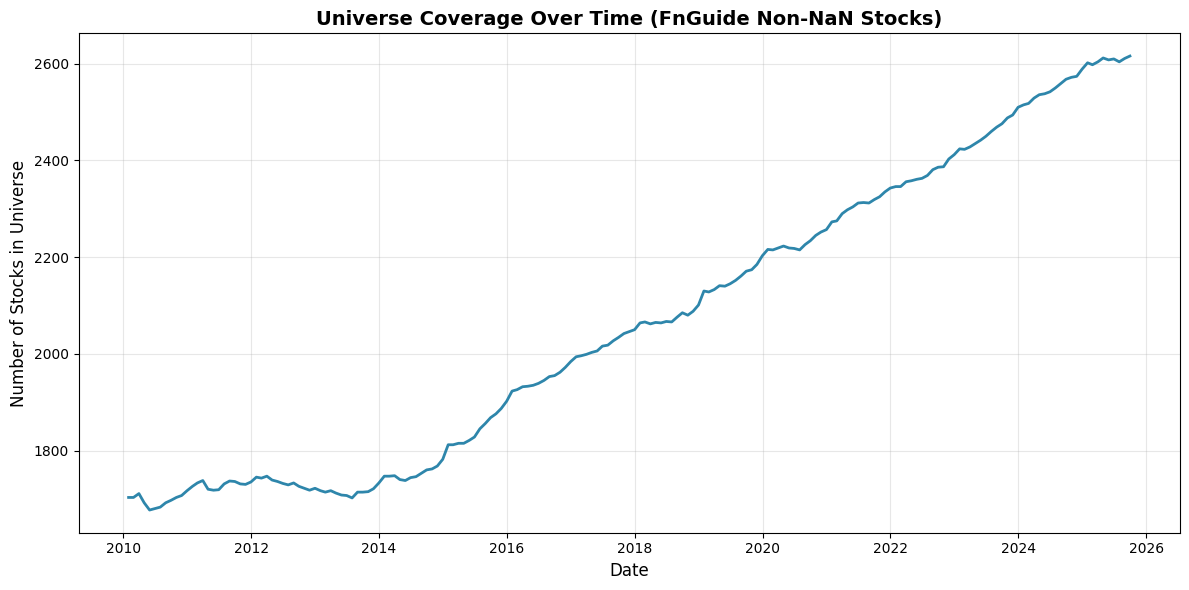

  Min stocks: 1677 on 2010-05-31
  Max stocks: 2616 on 2025-09-30
  Mean stocks: 2066

[OK] Universe coverage plot complete!


In [35]:
print("\nPlotting universe coverage over time...")

# Count non-NaN stocks cross-sectionally for each date
universe_coverage = sic_peer_returns_df.count(axis=1)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(universe_coverage.index, universe_coverage.values, linewidth=2, color='#2E86AB')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of Stocks in Universe', fontsize=12)
ax.set_title('Universe Coverage Over Time (FnGuide Non-NaN Stocks)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"  Min stocks: {universe_coverage.min()} on {universe_coverage.idxmin().strftime('%Y-%m-%d')}")
print(f"  Max stocks: {universe_coverage.max()} on {universe_coverage.idxmax().strftime('%Y-%m-%d')}")
print(f"  Mean stocks: {universe_coverage.mean():.0f}")

print("\n[OK] Universe coverage plot complete!")

## 10. Build TNIC Peer Lookup Dictionary

Create efficient lookup structure for TNIC peers:
- Filter is_same_tnic == True to get peer relationships
- Build dictionary: (stock_code, year) → [list of peer stock_codes]
- Identify orphan stocks (in universe but not in TNIC, or with zero peers)
- Exclude self-loops (firm as its own peer)

In [36]:
print_section("Build TNIC Peer Lookup Dictionary")

print("Step 1: Filter TNIC peer relationships (is_same_tnic == True)...")
tnic_peers_only = tnic_all_pairs[tnic_all_pairs['is_same_tnic'] == True].copy()
print(f"  Total TNIC peer relationships: {len(tnic_peers_only):,}")

print("\nStep 2: Check for orphan stocks (by year)...")

# Count orphans for each year (to avoid duplicates)
orphan_counts_by_year = {}
orphan_stocks_by_year = {}

for year, universe_stocks_tnic in universe_by_year.items():
    universe_set = set(universe_stocks_tnic)

    # Get stocks in TNIC for this year
    tnic_year_stocks = set(tnic_all_pairs[tnic_all_pairs['year'] == year]['stock_code_i'].unique())

    # Orphans: in universe but not in TNIC
    orphans_this_year = universe_set - tnic_year_stocks
    orphan_counts_by_year[year] = len(orphans_this_year)
    orphan_stocks_by_year[year] = orphans_this_year

print("Orphan stocks by year (in universe but not in TNIC):")
for year in sorted(orphan_counts_by_year.keys()):
    universe_size = len(universe_by_year[year])
    tnic_size = len(set(tnic_all_pairs[tnic_all_pairs['year'] == year]['stock_code_i'].unique()))
    orphan_size = orphan_counts_by_year[year]
    coverage = (1 - orphan_size / universe_size) * 100 if universe_size > 0 else 0
    print(f"  {year}: {orphan_size:4d} orphans (universe: {universe_size:4d}, TNIC: {tnic_size:4d}, coverage: {coverage:5.1f}%)")

# Overall unique orphans across all years
all_universe_stocks = set()
for stocks in universe_by_year.values():
    all_universe_stocks.update(stocks)

all_tnic_stocks = set(tnic_all_pairs['stock_code_i'].unique()) | set(tnic_all_pairs['stock_code_j'].unique())
orphan_missing_tnic = all_universe_stocks - all_tnic_stocks

print(f"\nTotal unique orphan stocks (across all years): {len(orphan_missing_tnic)}")
if len(orphan_missing_tnic) > 0:
    print(f"  Sample orphans: {list(orphan_missing_tnic)[:10]}")

print("\nStep 3: Build TNIC peer lookup dictionary...")

# Dictionary: (stock_code, year) → list of peer stock_codes
tnic_peer_dict = {}

# Statistics tracking
peer_counts_by_year = {}

for year in tqdm(range(2010, 2026), desc="Building lookup"):
    # Filter TNIC peers for this year
    tnic_year = tnic_peers_only[tnic_peers_only['year'] == year]

    peer_counts_this_year = []

    # For each unique stock in this year
    for stock_code in tnic_year['stock_code_i'].unique():
        # Get all peers (excluding self-loops)
        peers = tnic_year[
            (tnic_year['stock_code_i'] == stock_code) &
            (tnic_year['stock_code_j'] != stock_code)  # Exclude self-loops
        ]['stock_code_j'].tolist()

        # Store in dictionary
        tnic_peer_dict[(stock_code, year)] = peers
        peer_counts_this_year.append(len(peers))

    if len(peer_counts_this_year) > 0:
        peer_counts_by_year[year] = {
            'mean': np.mean(peer_counts_this_year),
            'median': np.median(peer_counts_this_year),
            'std': np.std(peer_counts_this_year),
            'max': np.max(peer_counts_this_year),
            'n_stocks': len(peer_counts_this_year)
        }

print(f"\n[OK] TNIC peer lookup dictionary built!")
print(f"     Total (stock, year) pairs: {len(tnic_peer_dict):,}")

print("\nStep 4: TNIC peer statistics by year...")
for year in sorted(peer_counts_by_year.keys()):
    stats = peer_counts_by_year[year]
    print(f"  {year}: {stats['n_stocks']:4d} stocks, "
          f"avg peers={stats['mean']:5.1f}, "
          f"median={stats['median']:4.0f}, "
          f"max={stats['max']:3.0f}")

# Overall statistics
all_peer_counts = [len(peers) for peers in tnic_peer_dict.values()]
print(f"\nOverall TNIC peer statistics (all years):")
print(f"  Average peers per stock: {np.mean(all_peer_counts):.1f}")
print(f"  Median peers per stock: {np.median(all_peer_counts):.0f}")
print(f"  Std dev: {np.std(all_peer_counts):.1f}")
print(f"  Max peers: {np.max(all_peer_counts)}")
print(f"  Min peers: {np.min(all_peer_counts)}")

# Checkpoint: Save TNIC peer dictionary
if args.save_checkpoints:
    print("\n[CHECKPOINT] Saving TNIC peer lookup dictionary...")
    cp.save_checkpoint(tnic_peer_dict, 'checkpoint_02_tnic_peer_dict.pkl', CHECKPOINT_DIR)


  Build TNIC Peer Lookup Dictionary

Step 1: Filter TNIC peer relationships (is_same_tnic == True)...
  Total TNIC peer relationships: 465,911

Step 2: Check for orphan stocks (by year)...
Orphan stocks by year (in universe but not in TNIC):
  2010:  779 orphans (universe: 1717, TNIC:  963, coverage:  54.6%)
  2011:  731 orphans (universe: 1735, TNIC: 1022, coverage:  57.9%)
  2012:  687 orphans (universe: 1722, TNIC: 1051, coverage:  60.1%)
  2013:  681 orphans (universe: 1733, TNIC: 1071, coverage:  60.7%)
  2014:  702 orphans (universe: 1782, TNIC: 1100, coverage:  60.6%)
  2015:  857 orphans (universe: 1902, TNIC: 1059, coverage:  54.9%)
  2016:  866 orphans (universe: 1984, TNIC: 1133, coverage:  56.4%)
  2017:  878 orphans (universe: 2050, TNIC: 1187, coverage:  57.2%)
  2018:  861 orphans (universe: 2101, TNIC: 1257, coverage:  59.0%)
  2019:  918 orphans (universe: 2203, TNIC: 1301, coverage:  58.3%)
  2020:  891 orphans (universe: 2257, TNIC: 1381, coverage:  60.5%)
  2021:  

Building lookup: 100%|██████████| 16/16 [00:52<00:00,  3.30s/it]


[OK] TNIC peer lookup dictionary built!
     Total (stock, year) pairs: 13,576

Step 4: TNIC peer statistics by year...
  2010:  718 stocks, avg peers= 20.0, median=   6, max=158
  2011:  778 stocks, avg peers= 22.2, median=   6, max=176
  2012:  473 stocks, avg peers= 37.6, median=   5, max=205
  2013:  573 stocks, avg peers= 30.5, median=   6, max=218
  2014:  669 stocks, avg peers= 28.4, median=   6, max=232
  2015:  380 stocks, avg peers= 48.4, median=  20, max=202
  2016:  434 stocks, avg peers= 46.6, median=  17, max=215
  2017:  425 stocks, avg peers= 53.8, median=  24, max=228
  2018:  470 stocks, avg peers= 54.3, median=  20, max=250
  2019:  579 stocks, avg peers= 46.8, median=  11, max=259
  2020:  672 stocks, avg peers= 42.6, median=  10, max=278
  2021:  736 stocks, avg peers= 43.5, median=   9, max=275
  2022: 1528 stocks, avg peers= 31.8, median=  11, max=354
  2023: 1586 stocks, avg peers= 28.1, median=  11, max=311
  2024: 1725 stocks, avg peers= 29.7, median=  11, ma

## 11. Calculate TNIC-Based Peer Returns

Calculate peer returns using TNIC network peers:
- Use 1-year lag: 2010 TNIC data → 2011 peer returns (avoid look-ahead bias)
- Only calculate for stocks in universe (fair comparison with FnGuide)
- Equal-weighted peer returns (matching paper methodology)
- Handle missing data gracefully (NaN for stocks with no peers or orphans)

In [37]:
print_section("Calculate TNIC-Based Peer Returns")

print("Initializing empty panel (same structure as monthly_returns_df)...")

# Initialize empty DataFrame with same shape as monthly_returns
tnic_peer_returns_df = pd.DataFrame(
    index=monthly_returns_df.index,
    columns=monthly_returns_df.columns,
    dtype=float
)

print(f"  Panel shape: {tnic_peer_returns_df.shape}")
print(f"  Date range: {tnic_peer_returns_df.index.min()} to {tnic_peer_returns_df.index.max()}")

print("\nCalculating TNIC peer returns with 1-year lag...")
print("  (2010 TNIC -> 2011 months, 2011 TNIC -> 2012 months, etc.)\n")

# Track statistics
n_calculated = 0
n_no_peers = 0
n_orphans = 0
n_skipped_no_tnic = 0

# Calculate TNIC peer returns
for date in tqdm(monthly_returns_df.index, desc="Processing dates"):
    current_year = date.year

    # Use previous year's TNIC data (1-year lag to avoid look-ahead bias)
    # 2010 TNIC -> 2011 months, 2011 TNIC -> 2012 months
    if current_year >= 2011:
        tnic_year = current_year - 1
    else:
        # Skip 2010 (no TNIC for 2009)
        n_skipped_no_tnic += len(monthly_returns_df.columns)
        continue

    # Get universe for current year (stock codes in TNIC format)
    universe_stocks_tnic = universe_by_year.get(current_year, [])

    for stock_code_tnic in universe_stocks_tnic:
        # stock_code_tnic is in TNIC format (e.g., "000020")

        # Lookup TNIC peers for this stock-year (peers are also in TNIC format)
        peers_tnic = tnic_peer_dict.get((stock_code_tnic, tnic_year), [])

        if len(peers_tnic) > 0:
            # Convert peer codes to FnGuide format for indexing monthly_returns_df
            peers_fnguide = [tnic_to_fnguide(p) for p in peers_tnic]

            # Filter to only peers that exist in monthly_returns columns
            valid_peers = [p for p in peers_fnguide if p in monthly_returns_df.columns]

            if len(valid_peers) > 0:
                peer_returns = monthly_returns_df.loc[date, valid_peers]

                # Equal-weighted average (NaN automatically excluded by .mean())
                # Store using FnGuide format (to match monthly_returns_df columns)
                stock_code_fnguide = tnic_to_fnguide(stock_code_tnic)
                tnic_peer_returns_df.loc[date, stock_code_fnguide] = peer_returns.mean()
                n_calculated += 1
            else:
                # Peers exist but none have return data
                stock_code_fnguide = tnic_to_fnguide(stock_code_tnic)
                tnic_peer_returns_df.loc[date, stock_code_fnguide] = np.nan
                n_no_peers += 1
        else:
            # No TNIC peers for this stock-year (orphan or no-peer stock)
            stock_code_fnguide = tnic_to_fnguide(stock_code_tnic)
            tnic_peer_returns_df.loc[date, stock_code_fnguide] = np.nan

            if stock_code_tnic in orphan_missing_tnic:
                n_orphans += 1
            else:
                n_no_peers += 1

print(f"\n[OK] TNIC peer returns calculated!")
print(f"     Successfully calculated: {n_calculated:,} stock-dates")
print(f"     No TNIC peers: {n_no_peers:,} stock-dates")
print(f"     Orphan stocks (missing TNIC): {n_orphans:,} stock-dates")
print(f"     Skipped (no TNIC for year): {n_skipped_no_tnic:,} stock-dates")

# Summary statistics
print(f"\nTNIC peer return statistics:")
print(f"  Shape: {tnic_peer_returns_df.shape}")
print(f"  Non-NaN values: {tnic_peer_returns_df.count().sum():,} ({tnic_peer_returns_df.count().sum() / tnic_peer_returns_df.size * 100:.1f}%)")
print(f"  Mean: {tnic_peer_returns_df.mean().mean():.6f}")
print(f"  Std: {tnic_peer_returns_df.std().mean():.6f}")
print(f"  Min: {tnic_peer_returns_df.min().min():.6f}")
print(f"  Max: {tnic_peer_returns_df.max().max():.6f}")

# Checkpoint: Save TNIC peer returns
if args.save_checkpoints:
    print("\n[CHECKPOINT] Saving TNIC peer returns...")
    cp.save_checkpoint(tnic_peer_returns_df, 'checkpoint_03_tnic_peer_returns.parquet', CHECKPOINT_DIR)


  Calculate TNIC-Based Peer Returns

Initializing empty panel (same structure as monthly_returns_df)...
  Panel shape: (189, 3263)
  Date range: 2010-01-31 00:00:00 to 2025-09-30 00:00:00

Calculating TNIC peer returns with 1-year lag...
  (2010 TNIC -> 2011 months, 2011 TNIC -> 2012 months, etc.)



Processing dates: 100%|██████████| 189/189 [00:50<00:00,  3.73it/s]


[OK] TNIC peer returns calculated!
     Successfully calculated: 119,508 stock-dates
     No TNIC peers: 121,992 stock-dates
     Orphan stocks (missing TNIC): 110,376 stock-dates
     Skipped (no TNIC for year): 39,156 stock-dates

TNIC peer return statistics:
  Shape: (189, 3263)
  Non-NaN values: 119,136 (19.3%)
  Mean: 0.005256
  Std: 0.094866
  Min: -0.685900
  Max: 2.791400


## 12. Identify TNIC High-Quintile Peer Shock Events

Event definition (same methodology as FnGuide):
- High-quintile = top 20% of cross-sectional TNIC peer returns each month
- For each month, calculate 80th percentile of all TNIC peer returns
- Mark firms whose TNIC peer return >= threshold as having an event

In [ ]:
print_section("Identify TNIC High-Quintile Peer Shock Events")

quintile_threshold = 0.80  # Top 20%

print(f"Quintile threshold: {quintile_threshold} (top {(1-quintile_threshold)*100:.0f}%)")
print("\nIdentifying TNIC events cross-sectionally for each month...")

tnic_event_matrix = pd.DataFrame(
    index=tnic_peer_returns_df.index,
    columns=tnic_peer_returns_df.columns,
    dtype=bool
)

for date in tnic_peer_returns_df.index:
    # Get TNIC peer returns for this date (cross-section)
    peer_returns_date = tnic_peer_returns_df.loc[date]
    valid_returns = peer_returns_date.dropna()

    if len(valid_returns) > 0:
        # Calculate 80th percentile
        threshold = valid_returns.quantile(quintile_threshold)

        # Mark events (peer return >= threshold)
        tnic_event_matrix.loc[date] = peer_returns_date >= threshold
    else:
        tnic_event_matrix.loc[date] = False

tnic_event_matrix = tnic_event_matrix.fillna(False)

total_tnic_events = tnic_event_matrix.sum().sum()
print(f"\n[OK] TNIC events identified!")
print(f"     Total events: {total_tnic_events:,}")
print(f"     Mean events per firm: {tnic_event_matrix.sum(axis=0).mean():.1f}")
print(f"     Mean events per month: {tnic_event_matrix.sum(axis=1).mean():.1f}")

# Compare with FnGuide events
print(f"\nComparison with FnGuide:")
print(f"     FnGuide total events: {total_events:,}")
print(f"     TNIC total events: {total_tnic_events:,}")
print(f"     Ratio (TNIC/FnGuide): {total_tnic_events / total_events:.2f}")

## 13. Extract TNIC Turnover Windows Around Events

Window structure (same as FnGuide):
- t-3 to t+12 (16 months total)
- t=0 is the event month (high-quintile TNIC peer shock)
- Require complete data (no missing turnover values)
- Prevent overlapping windows (earlier events take priority)

In [ ]:
print_section("Extract TNIC Turnover Windows")

turnover_windows_tnic = extract_turnover_windows(
    share_turnover_df,
    tnic_event_matrix,
    WINDOW_BEFORE,
    WINDOW_AFTER
)

print(f"[OK] TNIC method: {len(turnover_windows_tnic):,} valid windows")
print(f"     Acceptance rate: {len(turnover_windows_tnic) / total_tnic_events * 100:.1f}%")

print(f"\nComparison with FnGuide:")
print(f"     FnGuide valid windows: {len(turnover_windows_daily):,}")
print(f"     TNIC valid windows: {len(turnover_windows_tnic):,}")
print(f"     Ratio (TNIC/FnGuide): {len(turnover_windows_tnic) / len(turnover_windows_daily):.2f}")

## 14. Normalize and Plot TNIC Figure 1A

Paper methodology: "All results are scaled so that the first month has unit turnover"
- First month = t=-3
- Average first, then normalize
- Compare with FnGuide baseline

In [ ]:
print_section("Normalize TNIC Turnover")

normalized_turnover_tnic = normalize_and_aggregate(turnover_windows_tnic, WINDOW_BEFORE)

print(f"[OK] TNIC method normalized!")
print(f"Normalized turnover (t={-WINDOW_BEFORE} = 1.0):")
for i, val in enumerate(normalized_turnover_tnic):
    rel_month = i - WINDOW_BEFORE
    print(f"  t{rel_month:+3d}: {val:.4f}")

In [ ]:
print_section("Plot Figure 1A - TNIC Peer Network")

relative_months = np.arange(-WINDOW_BEFORE, WINDOW_AFTER + 1)

fig_tnic, ax_tnic = plot_results(
    relative_months,
    normalized_turnover_tnic,
    len(turnover_windows_tnic),
    "TNIC Peer Network",
    WINDOW_BEFORE,
    -WINDOW_BEFORE,  # Normalization point is t=-3
    legend_label="TNIC Network",
    color='#F26419'
)
plt.show()
print("[OK] TNIC plot complete!")

## 15. Comparison Plot: FnGuide vs TNIC

Direct visual comparison of turnover patterns:
- FnGuide Industry (highly visible peers)
- TNIC Network (less visible peers)

Hypothesis: TNIC should show longer persistence due to investor inattention

In [ ]:
print_section("Plot Comparison: FnGuide vs TNIC")

# Prepare data for comparison plot
turnover_series = [
    {
        'data': normalized_turnover_daily,
        'label': 'FnGuide Industry',
        'color': '#2E86AB',
        'marker': 'o',
        'n_events': len(turnover_windows_daily)
    },
    {
        'data': normalized_turnover_tnic,
        'label': 'TNIC Network',
        'color': '#F26419',
        'marker': 's',
        'n_events': len(turnover_windows_tnic)
    }
]

fig_comparison, ax_comparison = plot_comparison(
    relative_months,
    turnover_series,
    WINDOW_BEFORE=WINDOW_BEFORE,
    normalization_point=-WINDOW_BEFORE,
    title_suffix="Comparison: FnGuide Industry vs TNIC Network"
)

# Save Figure 1A
output_path_1a = Path("outputs") / "figure1a_unconditional_turnover.png"
output_path_1a.parent.mkdir(parents=True, exist_ok=True)
fig_comparison.savefig(output_path_1a, dpi=300, bbox_inches='tight')
print(f"[OK] Saved Figure 1A to: {output_path_1a}")

plt.show()

print("[OK] Comparison plot complete!")

## 16. Statistical Comparison: FnGuide vs TNIC

Quantitative comparison of turnover patterns:
- Event counts
- Turnover persistence (t=0, t+6, t+12)
- Hypothesis testing

In [ ]:
print_section("Statistical Comparison: FnGuide vs TNIC")

print("Event Statistics:")
print(f"  FnGuide total events: {total_events:,}")
print(f"  TNIC total events: {total_tnic_events:,}")
print(f"  FnGuide valid windows: {len(turnover_windows_daily):,} ({len(turnover_windows_daily)/total_events*100:.1f}% acceptance)")
print(f"  TNIC valid windows: {len(turnover_windows_tnic):,} ({len(turnover_windows_tnic)/total_tnic_events*100:.1f}% acceptance)")

print("\nNormalized Turnover at Key Time Points:")
print(f"  {'Time':<10} {'FnGuide':>12} {'TNIC':>12} {'Difference':>12}")
print(f"  {'-'*10} {'-'*12} {'-'*12} {'-'*12}")

key_points = [
    (-3, "t=-3 (norm)", -3),
    (0, "t=0 (event)", 0),
    (3, "t=+3", 3),
    (6, "t=+6", 6),
    (9, "t=+9", 9),
    (12, "t=+12", 12)
]

for rel_month, label, idx_offset in key_points:
    idx = WINDOW_BEFORE + idx_offset
    fnguide_val = normalized_turnover_daily[idx]
    tnic_val = normalized_turnover_tnic[idx]
    diff = tnic_val - fnguide_val
    print(f"  {label:<10} {fnguide_val:12.4f} {tnic_val:12.4f} {diff:+12.4f}")

print("\nTurnover Persistence Analysis:")
# Calculate average turnover in post-event windows
post_event_early = slice(WINDOW_BEFORE + 1, WINDOW_BEFORE + 4)  # t+1 to t+3
post_event_mid = slice(WINDOW_BEFORE + 4, WINDOW_BEFORE + 7)    # t+4 to t+6
post_event_late = slice(WINDOW_BEFORE + 7, WINDOW_BEFORE + 13)  # t+7 to t+12

fnguide_early = normalized_turnover_daily[post_event_early].mean()
fnguide_mid = normalized_turnover_daily[post_event_mid].mean()
fnguide_late = normalized_turnover_daily[post_event_late].mean()

tnic_early = normalized_turnover_tnic[post_event_early].mean()
tnic_mid = normalized_turnover_tnic[post_event_mid].mean()
tnic_late = normalized_turnover_tnic[post_event_late].mean()

print(f"  Average turnover t+1 to t+3:")
print(f"    FnGuide: {fnguide_early:.4f}")
print(f"    TNIC: {tnic_early:.4f}")
print(f"    Difference: {tnic_early - fnguide_early:+.4f}")

print(f"  Average turnover t+4 to t+6:")
print(f"    FnGuide: {fnguide_mid:.4f}")
print(f"    TNIC: {tnic_mid:.4f}")
print(f"    Difference: {tnic_mid - fnguide_mid:+.4f}")

print(f"  Average turnover t+7 to t+12:")
print(f"    FnGuide: {fnguide_late:.4f}")
print(f"    TNIC: {tnic_late:.4f}")
print(f"    Difference: {tnic_late - fnguide_late:+.4f}")

print("\n" + "=" * 80)
print("  TNIC FIGURE 1A ANALYSIS COMPLETE!")
print("=" * 80)

## 17. Calculate Quintile Rankings for Both Peer Groups

For Graph B, we need to identify conditional events:
- FnGuide Q5 AND TNIC Q3 (visible shock, invisible control)
- TNIC Q5 AND FnGuide Q3 (invisible shock, visible control)

Methodology:
- Use pd.qcut() for quintile assignment (equal-sized bins)
- Use pd.quantile() for threshold reporting (transparency)
- Handle ties with duplicates='drop'

In [ ]:
print_section("Calculate Quintile Rankings for Both Peer Groups")

print("Creating quintile matrices for FnGuide and TNIC peer returns...")
print("  Method: pd.qcut() for assignment (equal-sized bins)")
print("  Reporting: pd.quantile() for thresholds (transparency)\n")

# Initialize quintile matrices
quintile_fnguide = pd.DataFrame(
    index=sic_peer_returns_df.index,
    columns=sic_peer_returns_df.columns,
    dtype='Int64'  # Nullable integer type
)

quintile_tnic = pd.DataFrame(
    index=tnic_peer_returns_df.index,
    columns=tnic_peer_returns_df.columns,
    dtype='Int64'
)

# Track quintile assignment statistics
n_success_fnguide = 0
n_success_tnic = 0
n_fail_fnguide = 0
n_fail_tnic = 0

# Sample dates for threshold reporting (first, middle, last)
sample_dates = [
    sic_peer_returns_df.index[0],
    sic_peer_returns_df.index[len(sic_peer_returns_df)//2],
    sic_peer_returns_df.index[-1]
]

print("Calculating quintiles for each month...")
for date in sic_peer_returns_df.index:
    # FnGuide quintiles
    try:
        quintile_fnguide.loc[date] = pd.qcut(
            sic_peer_returns_df.loc[date],
            q=5,
            labels=[1, 2, 3, 4, 5],
            duplicates='drop'
        )
        n_success_fnguide += 1

        # Report thresholds for sample dates
        if date in sample_dates:
            q20 = sic_peer_returns_df.loc[date].quantile(0.20)
            q40 = sic_peer_returns_df.loc[date].quantile(0.40)
            q60 = sic_peer_returns_df.loc[date].quantile(0.60)
            q80 = sic_peer_returns_df.loc[date].quantile(0.80)
            print(f"  {date.strftime('%Y-%m-%d')} FnGuide quintile breakpoints:")
            print(f"    Q1-Q2: {q20:+.4f}, Q2-Q3: {q40:+.4f}, Q3-Q4: {q60:+.4f}, Q4-Q5: {q80:+.4f}")
    except (ValueError, TypeError) as e:
        quintile_fnguide.loc[date] = pd.NA
        n_fail_fnguide += 1

    # TNIC quintiles
    try:
        quintile_tnic.loc[date] = pd.qcut(
            tnic_peer_returns_df.loc[date],
            q=5,
            labels=[1, 2, 3, 4, 5],
            duplicates='drop'
        )
        n_success_tnic += 1

        # Report thresholds for sample dates
        if date in sample_dates:
            q20 = tnic_peer_returns_df.loc[date].quantile(0.20)
            q40 = tnic_peer_returns_df.loc[date].quantile(0.40)
            q60 = tnic_peer_returns_df.loc[date].quantile(0.60)
            q80 = tnic_peer_returns_df.loc[date].quantile(0.80)
            print(f"  {date.strftime('%Y-%m-%d')} TNIC quintile breakpoints:")
            print(f"    Q1-Q2: {q20:+.4f}, Q2-Q3: {q40:+.4f}, Q3-Q4: {q60:+.4f}, Q4-Q5: {q80:+.4f}")
    except (ValueError, TypeError) as e:
        quintile_tnic.loc[date] = pd.NA
        n_fail_tnic += 1

print(f"\n[OK] Quintile assignment complete!")
print(f"     FnGuide: {n_success_fnguide} successful, {n_fail_fnguide} failed")
print(f"     TNIC: {n_success_tnic} successful, {n_fail_tnic} failed")

# Verify quintile distributions
print(f"\nQuintile distribution check (should be ~20% each):")
for q in [1, 2, 3, 4, 5]:
    fnguide_pct = (quintile_fnguide == q).sum().sum() / quintile_fnguide.notna().sum().sum() * 100
    tnic_pct = (quintile_tnic == q).sum().sum() / quintile_tnic.notna().sum().sum() * 100
    print(f"  Q{q}: FnGuide {fnguide_pct:.1f}%, TNIC {tnic_pct:.1f}%")

# Checkpoint: Save quintiles (CRITICAL - saves 14 minutes!)
if args.save_checkpoints:
    print("\n[CHECKPOINT] Saving quintile rankings (14-minute calculation)...")
    # Combine into single file with multi-level index
    quintiles_combined = pd.concat([
        quintile_fnguide,
        quintile_tnic
    ], keys=['fnguide', 'tnic'], names=['source', 'date'])
    cp.save_checkpoint(quintiles_combined, 'checkpoint_01_quintiles.parquet', CHECKPOINT_DIR,
                      metadata={'description': 'Quintile rankings for both FnGuide and TNIC peer returns'})

## 18. Identify Conditional Events (Graph B)

Event definitions:
- Event Type 1: FnGuide Q5 AND TNIC Q3 (visible shock without invisible shock)
- Event Type 2: TNIC Q5 AND FnGuide Q3 (invisible shock without visible shock)

These events are mutually exclusive and test clean separation of peer group effects.

In [ ]:
print_section("Identify Conditional Events (Graph B)")

print("Event definitions:")
print("  Type 1: FnGuide Q5 AND TNIC Q3 (visible shock, invisible control)")
print("  Type 2: TNIC Q5 AND FnGuide Q3 (invisible shock, visible control)\n")

# Event Type 1: FnGuide Q5 AND TNIC Q3
event_fnguide_only = (quintile_fnguide == 5) & (quintile_tnic == 3)
event_fnguide_only = event_fnguide_only.fillna(False)

# Event Type 2: TNIC Q5 AND FnGuide Q3
event_tnic_only = (quintile_tnic == 5) & (quintile_fnguide == 3)
event_tnic_only = event_tnic_only.fillna(False)

# Count events
total_fnguide_only = event_fnguide_only.sum().sum()
total_tnic_only = event_tnic_only.sum().sum()

print(f"[OK] Conditional events identified!")
print(f"\nEvent Type 1 (FnGuide Q5 & TNIC Q3):")
print(f"  Total events: {total_fnguide_only:,}")
print(f"  Mean events per firm: {event_fnguide_only.sum(axis=0).mean():.1f}")
print(f"  Mean events per month: {event_fnguide_only.sum(axis=1).mean():.1f}")

print(f"\nEvent Type 2 (TNIC Q5 & FnGuide Q3):")
print(f"  Total events: {total_tnic_only:,}")
print(f"  Mean events per firm: {event_tnic_only.sum(axis=0).mean():.1f}")
print(f"  Mean events per month: {event_tnic_only.sum(axis=1).mean():.1f}")

# Compare with unconditional events (Graph A)
print(f"\nComparison with Graph A (unconditional events):")
print(f"  FnGuide Q5 (any TNIC): {total_events:,} events")
print(f"  FnGuide Q5 & TNIC Q3: {total_fnguide_only:,} events ({total_fnguide_only/total_events*100:.1f}%)")
print(f"  TNIC Q5 (any FnGuide): {total_tnic_events:,} events")
print(f"  TNIC Q5 & FnGuide Q3: {total_tnic_only:,} events ({total_tnic_only/total_tnic_events*100:.1f}%)")

# Check mutual exclusivity
overlap = (event_fnguide_only & event_tnic_only).sum().sum()
print(f"\nMutual exclusivity check:")
print(f"  Events in both types: {overlap} (should be 0)")

## 19. Extract Turnover Windows for Conditional Events

Extract turnover windows (t-3 to t+12) separately for each event type:
- FnGuide-only events
- TNIC-only events

Use same extraction logic as Graph A (reuse function).

In [ ]:
print_section("Extract Turnover Windows for Conditional Events")

print("Extracting windows for FnGuide-only events (FnGuide Q5 & TNIC Q3)...")
turnover_windows_fnguide_only = extract_turnover_windows(
    share_turnover_df,
    event_fnguide_only,
    WINDOW_BEFORE,
    WINDOW_AFTER
)

print(f"[OK] FnGuide-only: {len(turnover_windows_fnguide_only):,} valid windows")
print(f"     Acceptance rate: {len(turnover_windows_fnguide_only) / total_fnguide_only * 100:.1f}%")

print("\nExtracting windows for TNIC-only events (TNIC Q5 & FnGuide Q3)...")
turnover_windows_tnic_only = extract_turnover_windows(
    share_turnover_df,
    event_tnic_only,
    WINDOW_BEFORE,
    WINDOW_AFTER
)

print(f"[OK] TNIC-only: {len(turnover_windows_tnic_only):,} valid windows")
print(f"     Acceptance rate: {len(turnover_windows_tnic_only) / total_tnic_only * 100:.1f}%")

print(f"\nComparison with Graph A:")
print(f"  Graph A FnGuide (unconditional): {len(turnover_windows_daily):,} windows")
print(f"  Graph B FnGuide-only (conditional): {len(turnover_windows_fnguide_only):,} windows ({len(turnover_windows_fnguide_only)/len(turnover_windows_daily)*100:.1f}%)")
print(f"  Graph A TNIC (unconditional): {len(turnover_windows_tnic):,} windows")
print(f"  Graph B TNIC-only (conditional): {len(turnover_windows_tnic_only):,} windows ({len(turnover_windows_tnic_only)/len(turnover_windows_tnic)*100:.1f}%)")

## 20. Normalize and Plot Graph B

Normalize turnover by t=-3 and create comparison plot:
- FnGuide-only events (visible shock, invisible control)
- TNIC-only events (invisible shock, visible control)

Expected pattern (H&P 2018):
- FnGuide-only: Immediate spike at t=0, quick reversion
- TNIC-only: Delayed response, persistent elevation

In [ ]:
print_section("Normalize Turnover for Graph B")

# Normalize FnGuide-only events
normalized_turnover_fnguide_only = normalize_and_aggregate(
    turnover_windows_fnguide_only,
    WINDOW_BEFORE
)

print(f"[OK] FnGuide-only normalized!")
print(f"Normalized turnover (t={-WINDOW_BEFORE} = 1.0):")
for i, val in enumerate(normalized_turnover_fnguide_only):
    rel_month = i - WINDOW_BEFORE
    print(f"  t{rel_month:+3d}: {val:.4f}")

# Normalize TNIC-only events
print(f"\n")
normalized_turnover_tnic_only = normalize_and_aggregate(
    turnover_windows_tnic_only,
    WINDOW_BEFORE
)

print(f"[OK] TNIC-only normalized!")
print(f"Normalized turnover (t={-WINDOW_BEFORE} = 1.0):")
for i, val in enumerate(normalized_turnover_tnic_only):
    rel_month = i - WINDOW_BEFORE
    print(f"  t{rel_month:+3d}: {val:.4f}")

In [ ]:
print_section("Plot Figure 1B - Conditional Turnover")

relative_months = np.arange(-WINDOW_BEFORE, WINDOW_AFTER + 1)

# Prepare data for comparison plot
turnover_series_conditional = [
    {
        'data': normalized_turnover_fnguide_only,
        'label': 'FnGuide Q5 & TNIC Q3',
        'color': '#2E86AB',
        'marker': 'o',
        'n_events': len(turnover_windows_fnguide_only)
    },
    {
        'data': normalized_turnover_tnic_only,
        'label': 'TNIC Q5 & FnGuide Q3',
        'color': '#F26419',
        'marker': 's',
        'n_events': len(turnover_windows_tnic_only)
    }
]

fig_graph_b, ax_graph_b = plot_comparison(
    relative_months,
    turnover_series_conditional,
    WINDOW_BEFORE=WINDOW_BEFORE,
    normalization_point=-WINDOW_BEFORE,
    title_suffix="Graph B: Conditional Events (Peer Group Separation)"
)

# Save Figure 1B
output_path_1b = Path("outputs") / "figure1b_conditional_turnover.png"
output_path_1b.parent.mkdir(parents=True, exist_ok=True)
fig_graph_b.savefig(output_path_1b, dpi=300, bbox_inches='tight')
print(f"[OK] Saved Figure 1B to: {output_path_1b}")

plt.show()

print("[OK] Graph B plot complete!")

## 21. Statistical Comparison: Conditional vs Unconditional Events

Compare Graph A (unconditional) vs Graph B (conditional) patterns:
- Test H&P hypothesis about delayed attention to less visible peers
- Analyze persistence differences
- Quantify the separation effect

In [ ]:
print_section("Statistical Comparison: Graph B vs Graph A")

print("=" * 80)
print("GRAPH A (UNCONDITIONAL) vs GRAPH B (CONDITIONAL)")
print("=" * 80)

print("\nEvent Counts:")
print(f"  Graph A - FnGuide (any TNIC):")
print(f"    Events: {total_events:,}, Windows: {len(turnover_windows_daily):,}")
print(f"  Graph B - FnGuide Q5 & TNIC Q3:")
print(f"    Events: {total_fnguide_only:,}, Windows: {len(turnover_windows_fnguide_only):,}")
print(f"    Ratio: {total_fnguide_only/total_events:.1%} of unconditional")

print(f"\n  Graph A - TNIC (any FnGuide):")
print(f"    Events: {total_tnic_events:,}, Windows: {len(turnover_windows_tnic):,}")
print(f"  Graph B - TNIC Q5 & FnGuide Q3:")
print(f"    Events: {total_tnic_only:,}, Windows: {len(turnover_windows_tnic_only):,}")
print(f"    Ratio: {total_tnic_only/total_tnic_events:.1%} of unconditional")

print("\nNormalized Turnover at Key Time Points:")
print(f"  {'Time':<12} {'FnG Uncond':>12} {'FnG Cond':>12} {'TNIC Uncond':>12} {'TNIC Cond':>12}")
print(f"  {'-'*12} {'-'*12} {'-'*12} {'-'*12} {'-'*12}")

for rel_month, label, idx_offset in key_points:
    idx = WINDOW_BEFORE + idx_offset
    fnguide_uncond = normalized_turnover_daily[idx]
    fnguide_cond = normalized_turnover_fnguide_only[idx]
    tnic_uncond = normalized_turnover_tnic[idx]
    tnic_cond = normalized_turnover_tnic_only[idx]
    print(f"  {label:<12} {fnguide_uncond:12.4f} {fnguide_cond:12.4f} {tnic_uncond:12.4f} {tnic_cond:12.4f}")

print("\nPersistence Analysis (Average Turnover by Period):")

# Calculate persistence metrics
periods = [
    (slice(WINDOW_BEFORE + 1, WINDOW_BEFORE + 4), "t+1 to t+3 (early)"),
    (slice(WINDOW_BEFORE + 4, WINDOW_BEFORE + 7), "t+4 to t+6 (mid)"),
    (slice(WINDOW_BEFORE + 7, WINDOW_BEFORE + 13), "t+7 to t+12 (late)")
]

for period_slice, period_label in periods:
    fnguide_uncond = normalized_turnover_daily[period_slice].mean()
    fnguide_cond = normalized_turnover_fnguide_only[period_slice].mean()
    tnic_uncond = normalized_turnover_tnic[period_slice].mean()
    tnic_cond = normalized_turnover_tnic_only[period_slice].mean()

    print(f"\n  {period_label}:")
    print(f"    FnGuide unconditional: {fnguide_uncond:.4f}")
    print(f"    FnGuide conditional:   {fnguide_cond:.4f} (diff: {fnguide_cond-fnguide_uncond:+.4f})")
    print(f"    TNIC unconditional:    {tnic_uncond:.4f}")
    print(f"    TNIC conditional:      {tnic_cond:.4f} (diff: {tnic_cond-tnic_uncond:+.4f})")

print("\n" + "=" * 80)
print("  FIGURE 1B ANALYSIS COMPLETE!")
print("=" * 80)

## 21. Table 1 Panel A: Summary Statistics

Calculate Fama-French control variables and generate summary statistics
for regression analysis (Table 1 Panel A from Hoberg & Phillips 2018).

Variables required:
1. Monthly return (focal firm)
2. Log book-to-market ratio (with Fama-French lag)
3. Log market size (with Fama-French lag)
4. Month t-1 past return
5. Month t-2 to t-12 cumulative past return

In [ ]:
print_section("Table 1 Panel A: Summary Statistics")

print("Loading fundamental data for BE/ME calculation...")

# Step 1: Load Book Equity Components
# Note: Fundamental data is quarterly (Q1-Q4 have same values within each quarter)
# We need annual balance sheet values, so resample to yearly and divide by 4
be_components = (
    fm('fnguide_common_stock_capital') +
    fm('fnguide_capital_surplus') +
    fm('fnguide_retained_earnings') +
    fm('fnguide_treasury_stock') +
    fm('fnguide_deferred_tax_liabilities')
)
be_df = be_components.to_df()

print(f"  BE components loaded: {be_df.shape}")
print(f"  Date range: {be_df.index.min()} to {be_df.index.max()}")

# Resample to annual frequency, sum across year, divide by 4 to get annual value
# (since quarterly data repeats same value 4 times per year)
be_annual = be_df.resample('YE').sum() / 4

# Extract December year-end values
be_dec = be_annual[be_annual.index.month == 12].copy()

print(f"  December BE values: {be_dec.shape}")
print(f"  Years covered: {be_dec.index.year.min()} to {be_dec.index.year.max()}")

# Step 2: Load Market Capitalization
me_monthly = fm('monthly_market_cap').to_df()

print(f"\nMarket cap loaded: {me_monthly.shape}")

# Extract December values (for BE/ME calculation)
me_dec = me_monthly[me_monthly.index.month == 12].copy()
print(f"  December ME values: {me_dec.shape}")

# Extract June values (for Size calculation)
me_june = me_monthly[me_monthly.index.month == 6].copy()
print(f"  June ME values: {me_june.shape}")

# Step 3: Calculate BE/ME with Fama-French Lag
print("\nApplying Fama-French lag convention to BE/ME...")
print("  December year t-1 BE/ME -> Apply to July year t through June year t+1")

# Calculate BE/ME at December year t-1
be_me_dec = be_dec / me_dec

print(f"  BE/ME calculated for {len(be_me_dec)} years")
print(f"  Negative BE values: {(be_dec < 0).sum().sum()}")
print(f"  Zero/NaN BE/ME values: {be_me_dec.isna().sum().sum()}")

# Apply Fama-French lag convention
# December year t-1 ratio -> Apply to July year t through June year t+1
be_me_lagged = {}

for dec_date in be_me_dec.index:
    year = dec_date.year
    # Apply to July year+1 through June year+2
    for month in range(7, 13):  # July to December
        month_end = pd.Timestamp(f'{year+1}-{month:02d}-01') + pd.offsets.MonthEnd(0)
        if month_end <= pd.Timestamp('2025-09-30'):  # Don't exceed our data range
            be_me_lagged[month_end] = be_me_dec.loc[dec_date]
    for month in range(1, 7):   # January to June
        month_end = pd.Timestamp(f'{year+2}-{month:02d}-01') + pd.offsets.MonthEnd(0)
        if month_end <= pd.Timestamp('2025-09-30'):
            be_me_lagged[month_end] = be_me_dec.loc[dec_date]

# Reconstruct DataFrame (dates × stocks)
be_me_df = pd.DataFrame(be_me_lagged).T
be_me_df = be_me_df.reindex(columns=monthly_returns_df.columns)

# Calculate log(BE/ME)
# Note: NaN where BE <= 0 or ME <= 0. These should be filtered in regressions.
log_be_me_df = np.log(be_me_df)

print(f"  BE/ME lagged dataframe: {be_me_df.shape}")
print(f"  Log(BE/ME) NaN values: {log_be_me_df.isna().sum().sum()}")

# Step 4: Calculate Size with Fama-French Lag
print("\nApplying Fama-French lag convention to Size...")
print("  June year t market cap -> Apply to July year t through June year t+1")

# June year t -> Apply to July year t through June year t+1
size_lagged = {}

for june_date in me_june.index:
    year = june_date.year
    # Apply to July year t through June year t+1
    for month in range(7, 13):  # July to December of same year
        month_end = pd.Timestamp(f'{year}-{month:02d}-01') + pd.offsets.MonthEnd(0)
        if month_end <= pd.Timestamp('2025-09-30'):
            size_lagged[month_end] = me_june.loc[june_date]
    for month in range(1, 7):   # January to June of next year
        month_end = pd.Timestamp(f'{year+1}-{month:02d}-01') + pd.offsets.MonthEnd(0)
        if month_end <= pd.Timestamp('2025-09-30'):
            size_lagged[month_end] = me_june.loc[june_date]

# Reconstruct DataFrame (dates × stocks)
size_df = pd.DataFrame(size_lagged).T
size_df = size_df.reindex(columns=monthly_returns_df.columns)

# Calculate log(Size)
log_size_df = np.log(size_df)

print(f"  Size lagged dataframe: {size_df.shape}")
print(f"  Log(Size) NaN values: {log_size_df.isna().sum().sum()}")

# Step 5: Calculate Past Return Variables
print("\nCalculating past return variables...")

# t-1 past return (simple shift by 1 month)
ret_t1_df = monthly_returns_df.shift(1)

# t-2 to t-12 cumulative return (11-month rolling sum, shift by 2)
ret_t2_t12_df = monthly_returns_df.rolling(window=11).sum().shift(2)

print(f"  Month t-1 return: {ret_t1_df.shape}")
print(f"  Month t-2 to t-12 return: {ret_t2_t12_df.shape}")

# Step 6: Compile Panel A Data
print("\nCompiling Panel A variables...")

panel_a_data = {
    '(1) Monthly return': monthly_returns_df,
    '(2) Log book-to-market': log_be_me_df,
    '(3) Log market size': log_size_df,
    '(4) Month t-1 return': ret_t1_df,
    '(5) Month t-2 to t-12 return': ret_t2_t12_df
}

# Step 7: Calculate Summary Statistics
print("\nCalculating summary statistics...")

summary_stats = []

for var_name, var_df in panel_a_data.items():
    stats = calculate_summary_stats_single(var_df, var_name)
    summary_stats.append(stats)
    values = var_df.stack().dropna()
    print(f"  {var_name}: N={len(values):,}, Mean={values.mean():.4f}")

panel_a_summary = pd.DataFrame(summary_stats)

# Step 8: Display Results
print("\n" + "="*80)
print(" " * 20 + "TABLE 1 - PANEL A: SUMMARY STATISTICS")
print("="*80)
print(panel_a_summary.to_string(index=False))
print("="*80)

print("\n" + "=" * 80)
print("  TABLE 1 PANEL A COMPLETE!")
print("=" * 80)

# Checkpoint: Save Fama-French control variables
if args.save_checkpoints:
    print("\n[CHECKPOINT] Saving Fama-French control variables...")
    ff_controls = pd.concat([
        log_be_me_df,
        log_size_df,
        ret_t1_df,
        ret_t2_t12_df
    ], keys=['log_be_me', 'log_size', 'ret_t1', 'ret_t2_t12'], names=['variable', 'date'])
    cp.save_checkpoint(ff_controls, 'checkpoint_06_ff_controls.parquet', CHECKPOINT_DIR,
                      metadata={'description': 'Fama-French control variables for regressions'})

## 22. Table 1 Panel B: SIC Peer Return Statistics

In [ ]:
print_section("Table 1 Panel B: SIC Peer Return Statistics")

print("Calculating SIC peer return variables...")

# Month t-1 past return
sic_peer_ret_t1 = sic_peer_returns_df.shift(1)

# Month t-1 to t-3 (3-month cumulative)
sic_peer_ret_t1_t3 = sic_peer_returns_df.rolling(window=3).sum().shift(1)

# Month t-1 to t-6 (6-month cumulative)
sic_peer_ret_t1_t6 = sic_peer_returns_df.rolling(window=6).sum().shift(1)

# Month t-1 to t-12 (12-month cumulative)
sic_peer_ret_t1_t12 = sic_peer_returns_df.rolling(window=12).sum().shift(1)

print(f"  SIC peer return variables calculated")
print(f"  Shape: {sic_peer_ret_t1.shape}")

# Calculate summary statistics
panel_b_data = [
    ('(1) Month t-1', sic_peer_ret_t1),
    ('(2) Month t-1 to t-3', sic_peer_ret_t1_t3),
    ('(3) Month t-1 to t-6', sic_peer_ret_t1_t6),
    ('(4) Month t-1 to t-12', sic_peer_ret_t1_t12)
]

print("\nCalculating summary statistics...")
summary_stats = []
for var_name, var_df in panel_b_data:
    stats = calculate_summary_stats_single(var_df, var_name)
    summary_stats.append(stats)
    values = var_df.stack().dropna()
    print(f"  {var_name}: N={len(values):,}, Mean={values.mean():.4f}")

panel_b_summary = pd.DataFrame(summary_stats)

# Display
print("\n" + "="*80)
print(" " * 15 + "TABLE 1 - PANEL B: SIC PEER RETURN STATISTICS")
print("="*80)
print(panel_b_summary.to_string(index=False))
print("="*80)

print("\n" + "=" * 80)
print("  TABLE 1 PANEL B COMPLETE!")
print("=" * 80)

## 23. Table 1 Panel C: TNIC Peer Return Statistics

In [ ]:
print_section("Table 1 Panel C: TNIC Peer Return Statistics")

print("Calculating TNIC peer return variables...")

# Month t-1 past return
tnic_peer_ret_t1 = tnic_peer_returns_df.shift(1)

# Month t-1 to t-3 (3-month cumulative)
tnic_peer_ret_t1_t3 = tnic_peer_returns_df.rolling(window=3).sum().shift(1)

# Month t-1 to t-6 (6-month cumulative)
tnic_peer_ret_t1_t6 = tnic_peer_returns_df.rolling(window=6).sum().shift(1)

# Month t-1 to t-12 (12-month cumulative)
tnic_peer_ret_t1_t12 = tnic_peer_returns_df.rolling(window=12).sum().shift(1)

print(f"  TNIC peer return variables calculated")
print(f"  Shape: {tnic_peer_ret_t1.shape}")

# Calculate summary statistics
panel_c_data = [
    ('(1) Month t-1', tnic_peer_ret_t1),
    ('(2) Month t-1 to t-3', tnic_peer_ret_t1_t3),
    ('(3) Month t-1 to t-6', tnic_peer_ret_t1_t6),
    ('(4) Month t-1 to t-12', tnic_peer_ret_t1_t12)
]

print("\nCalculating summary statistics...")
summary_stats = []
for var_name, var_df in panel_c_data:
    stats = calculate_summary_stats_single(var_df, var_name)
    summary_stats.append(stats)
    values = var_df.stack().dropna()
    print(f"  {var_name}: N={len(values):,}, Mean={values.mean():.4f}")

panel_c_summary = pd.DataFrame(summary_stats)

# Display
print("\n" + "="*80)
print(" " * 15 + "TABLE 1 - PANEL C: TNIC PEER RETURN STATISTICS")
print("="*80)
print(panel_c_summary.to_string(index=False))
print("="*80)

print("\n" + "=" * 80)
print("  TABLE 1 PANEL C COMPLETE!")
print("=" * 80)

## 24. Table 1 Panel D: Pearson Correlations

In [ ]:
print_section("Table 1 Panel D: Pearson Correlations")

print("Preparing variables for correlation analysis...")

# Stack variables: (time, security) → single Series per variable
corr_vars = {
    'Month t own return': monthly_returns_df.stack(),
    'Month t Log(BE/ME)': log_be_me_df.stack(),
    'Month t Log(Size)': log_size_df.stack(),
    'Month t-1 own return': monthly_returns_df.shift(1).stack(),
    'Month t-1 SIC peer': sic_peer_returns_df.shift(1).stack(),
    'Month t-1 TNIC peer': tnic_peer_returns_df.shift(1).stack()
}

# Combine into single DataFrame for correlation
corr_df = pd.DataFrame(corr_vars)

print(f"  Correlation dataframe shape: {corr_df.shape}")
print(f"  Non-NaN observations: {corr_df.notna().all(axis=1).sum():,}")

# Calculate Pearson correlation matrix
print("\nCalculating Pearson correlations...")
correlation_matrix = corr_df.corr()

# Display
print("\n" + "="*80)
print(" " * 20 + "TABLE 1 - PANEL D: PEARSON CORRELATIONS")
print("="*80)
print(correlation_matrix.to_string(float_format=lambda x: f'{x:.4f}'))
print("="*80)

print("\n" + "=" * 80)
print("  TABLE 1 PANEL D COMPLETE!")
print("=" * 80)

In [ ]:
# Create manifest if checkpoints were saved
if args.save_checkpoints:
    print("\n" + "=" * 80)
    print("  GENERATING CHECKPOINT MANIFEST")
    print("=" * 80)

    # Compute source data hashes for validation
    source_metadata = cp.compute_source_hash(
        monthly_returns_df,
        Path("data/korean_tnic/by_year")
    )

    # Create manifest with all checkpoint metadata
    manifest = cp.create_manifest(CHECKPOINT_DIR, source_metadata)

    print(f"\n[SUCCESS] All checkpoints saved to {CHECKPOINT_DIR}/")
    print(f"          {len(manifest['checkpoints'])} checkpoints ready for reuse")

# Validate checkpoints if requested
if args.validate_checkpoints:
    print("\n" + "=" * 80)
    print("  VALIDATING CHECKPOINTS")
    print("=" * 80)

    is_valid = cp.validate_checkpoints(CHECKPOINT_DIR, verbose=True)

    if is_valid:
        print("\n[SUCCESS] All checkpoints are valid!")
    else:
        print("\n[WARNING] Some checkpoints are invalid. Consider regenerating with --save-checkpoints")

In [ ]:
# Print timing summary
print_total_time()